In [ ]:
# ==============================
# 2. IMPORTS
# ==============================
import os
import zipfile
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import confusion_matrix, classification_report, f1_score


# ==============================
# 3. RUTAS
# ==============================

from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/ML"

train_zip = os.path.join(base_path, "x_train.zip")
test_zip  = os.path.join(base_path, "x_test.zip")
train_csv = os.path.join(base_path, "y_train_v2.csv")

# LOCAL extraction (fast)
train_path = "/content/proy/x_train"
test_path  = "/content/proy/x_test"


# ==============================
# 4. DESCOMPRIMIR (RÁPIDO)
# ==============================
with zipfile.ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall(train_path)

with zipfile.ZipFile(test_zip, 'r') as zip_ref:
    zip_ref.extractall(test_path)


# ============================================================
# FINAL PROJECT CODE + REPORT METRICS
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader,
    Subset,
    WeightedRandomSampler
)

from torchvision import transforms, models

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BASE = "/content/proy"

TRAIN = f"{BASE}/x_train"
TEST = f"{BASE}/x_test"
CSV = train_csv



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------

class RadarDataset(Dataset):

    def __init__(self, folder, csv=None, transform=None):
        self.folder = folder
        self.transform = transform

        self.files = sorted(
            os.listdir(folder),
            key=lambda x: int(x.split("_")[1].split(".")[0])
        )

        self.labels = None

        if csv:
            self.labels = pd.read_csv(csv)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.folder, self.files[idx])).convert("RGB")

        if self.transform:
            img = self.transform(img)

        if self.labels is not None:
            y = int(self.labels.iloc[idx, 1])
            return img, y

        return img, self.files[idx]


# ------------------------------------------------------------
# TRANSFORMS
# ------------------------------------------------------------

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# ------------------------------------------------------------
# SPLIT
# ------------------------------------------------------------

labels = pd.read_csv(CSV).iloc[:, 1].values

idx = np.arange(len(labels))

train_idx, val_idx = train_test_split(
    idx, test_size=0.15, stratify=labels, random_state=42
)

train_full = RadarDataset(TRAIN, CSV, train_tf)
val_full = RadarDataset(TRAIN, CSV, val_tf)

train_ds = Subset(train_full, train_idx)
val_ds = Subset(val_full, val_idx)


# ------------------------------------------------------------
# BALANCED SAMPLER
# ------------------------------------------------------------

counts = np.bincount(labels)
w = 1. / counts
sample_weights = [w[labels[i]] for i in train_idx]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=32)


# ------------------------------------------------------------
# MIXUP
# ------------------------------------------------------------

def mixup(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(device)
    mixed = lam * x + (1 - lam) * x[idx]
    y1, y2 = y, y[idx]
    return mixed, y1, y2, lam


# ------------------------------------------------------------
# FOCAL LOSS
# ------------------------------------------------------------

class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(self, x, y):
        ce = nn.functional.cross_entropy(x, y, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


criterion = FocalLoss()



In [ ]:

# ------------------------------------------------------------
# MODEL A: RadarCNN
# ------------------------------------------------------------

class RadarCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        x = self.net(x)
        return self.fc(x)


# ------------------------------------------------------------
# MODELOS: ResNet18, ResNet50, EfficientNet-B0
# ------------------------------------------------------------

# Model 1: RadarCNN (defined above)
model1 = RadarCNN().to(device)

#Model 2: ResNet50 (original)
model2 = models.resnet50(weights='IMAGENET1K_V2')
model2.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model2.fc.in_features, 4)
)
model2 = model2.to(device)

#Model 3: ResNet18(new)
model3 = models.resnet18(weights='IMAGENET1K_V1')
model3.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model3.fc.in_features, 4)
)
model3 = model3.to(device)

#Model 4: EfficientNet-B0(new)
model4 = models.efficientnet_b0(weights='IMAGENET1K_V1')
model4.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model4.classifier[1].in_features, 4)
)
model4 = model4.to(device)


# ------------------------------------------------------------
# TRAINING FUNCTION (IMPROVED to save F1)
# ------------------------------------------------------------

def train_one_model_advanced(model, name, train_loader, val_loader, epochs=20):
    best_f1 = 0
    best_w = None
    best_epoch = 0
    best_f1_per_class = None
    best_preds = None
    best_gt = None

    train_losses = []
    val_accs = []
    val_f1_macros = []

    opt = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            x, y1, y2, lam = mixup(x, y)

            opt.zero_grad()
            out = model(x)
            loss = lam * criterion(out, y1) + (1 - lam) * criterion(out, y2)
            loss.backward()
            opt.step()
            running_loss += loss.item()

        sched.step()
        train_losses.append(running_loss / len(train_loader))

        # Validation
        model.eval()
        preds = []
        gt = []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                out = model(x)
                p = out.argmax(1)
                preds.extend(p.cpu().numpy())
                gt.extend(y.numpy())

        acc = np.mean(np.array(preds) == np.array(gt))
        f1_macro = f1_score(gt, preds, average='macro')
        f1_per_class = f1_score(gt, preds, average=None)

        val_accs.append(acc)
        val_f1_macros.append(f1_macro)

        print(f"{name} epoch {epoch+1}: Acc={acc:.4f}, F1_macro={f1_macro:.4f}")

        # Save better model by F1 macro
        if f1_macro > best_f1:
            best_f1 = f1_macro
            best_epoch = epoch
            best_w = copy.deepcopy(model.state_dict())
            best_f1_per_class = f1_per_class.copy()
            best_preds = preds.copy()
            best_gt = gt.copy()

   # Load the best model
    model.load_state_dict(best_w)

    return {
        "loss": train_losses,
        "acc": val_accs,
        "f1_macro": val_f1_macros,
        "preds": best_preds,
        "gt": best_gt,
        "best_acc": max(val_accs),
        "best_f1": best_f1,
        "best_epoch": best_epoch,
        "best_f1_per_class": best_f1_per_class
    }



Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 86.6MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 70.3MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 50.9MB/s]


In [ ]:

# ------------------------------------------------------------
# TRAIN THE 4 MODELS
# ------------------------------------------------------------

print("\n" + "="*60)
print("ENTRENANDO 4 MODELOS")
print("="*60 + "\n")

history = {}

# RadarCNN
print("Modelo 1/4: RadarCNN")
history["RadarCNN"] = train_one_model_advanced(model1, "RadarCNN", train_loader, val_loader, epochs=20)

# ResNet50
print("\nModelo 2/4: ResNet50")
history["ResNet50"] = train_one_model_advanced(model2, "ResNet50", train_loader, val_loader, epochs=20)

# ResNet18
print("\nModelo 3/4: ResNet18")
history["ResNet18"] = train_one_model_advanced(model3, "ResNet18", train_loader, val_loader, epochs=20)

# EfficientNet-B0
print("\nModelo 4/4: EfficientNet-B0")
history["EfficientNet-B0"] = train_one_model_advanced(model4, "EfficientNet-B0", train_loader, val_loader, epochs=20)




ENTRENANDO 4 MODELOS

Modelo 1/4: RadarCNN
RadarCNN epoch 1: Acc=0.4123, F1_macro=0.3830
RadarCNN epoch 2: Acc=0.4975, F1_macro=0.4940
RadarCNN epoch 3: Acc=0.4339, F1_macro=0.4574
RadarCNN epoch 4: Acc=0.5379, F1_macro=0.5158
RadarCNN epoch 5: Acc=0.5357, F1_macro=0.5509
RadarCNN epoch 6: Acc=0.5531, F1_macro=0.5819
RadarCNN epoch 7: Acc=0.5516, F1_macro=0.5745
RadarCNN epoch 8: Acc=0.6152, F1_macro=0.6060
RadarCNN epoch 9: Acc=0.5365, F1_macro=0.5707
RadarCNN epoch 10: Acc=0.5690, F1_macro=0.5884
RadarCNN epoch 11: Acc=0.6556, F1_macro=0.6283
RadarCNN epoch 12: Acc=0.5487, F1_macro=0.5789
RadarCNN epoch 13: Acc=0.6390, F1_macro=0.6384
RadarCNN epoch 14: Acc=0.6058, F1_macro=0.6147
RadarCNN epoch 15: Acc=0.6469, F1_macro=0.6554
RadarCNN epoch 16: Acc=0.6570, F1_macro=0.6519
RadarCNN epoch 17: Acc=0.6527, F1_macro=0.6624
RadarCNN epoch 18: Acc=0.6159, F1_macro=0.6342
RadarCNN epoch 19: Acc=0.6419, F1_macro=0.6478
RadarCNN epoch 20: Acc=0.6375, F1_macro=0.6466

Modelo 2/4: ResNet50
Res

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

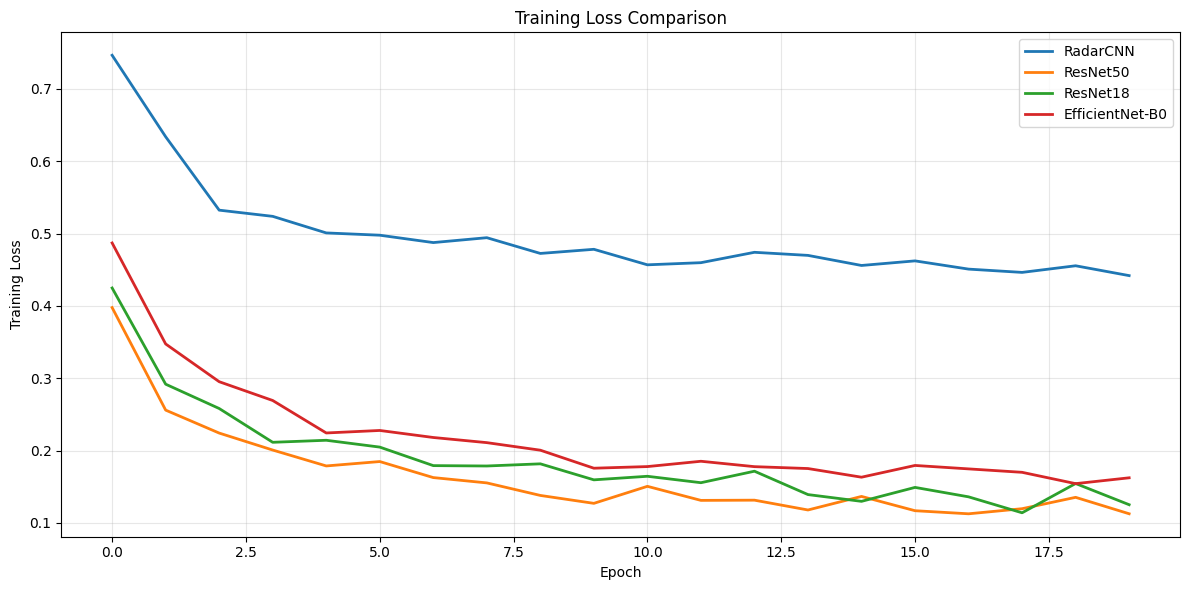

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

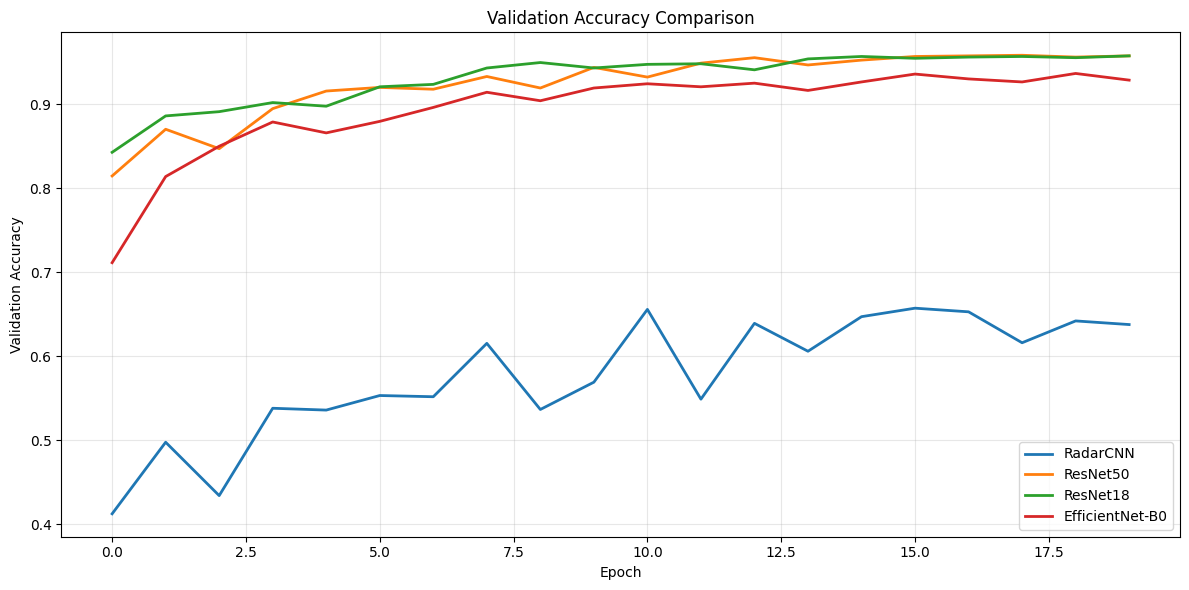

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

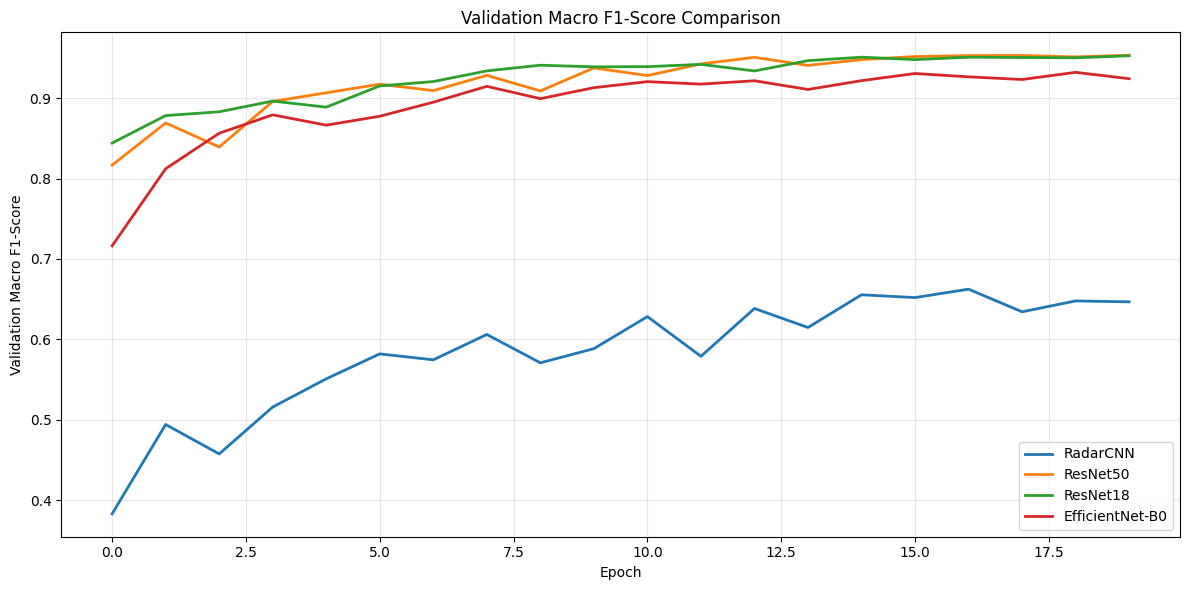


F1-SCORE PER CLASS (BEST EPOCH)

Model              F1 Macro   C0       C1       C2       C3       Epoch 
----------------------------------------------------------------------
RadarCNN           0.6624     0.9558   0.6375   0.5857   0.4706   17    
ResNet50           0.9534     0.9955   0.9651   0.9456   0.9073   20    
ResNet18           0.9527     0.9955   0.9634   0.9490   0.9030   20    
EfficientNet-B0    0.9321     0.9932   0.9467   0.9173   0.8713   19    


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

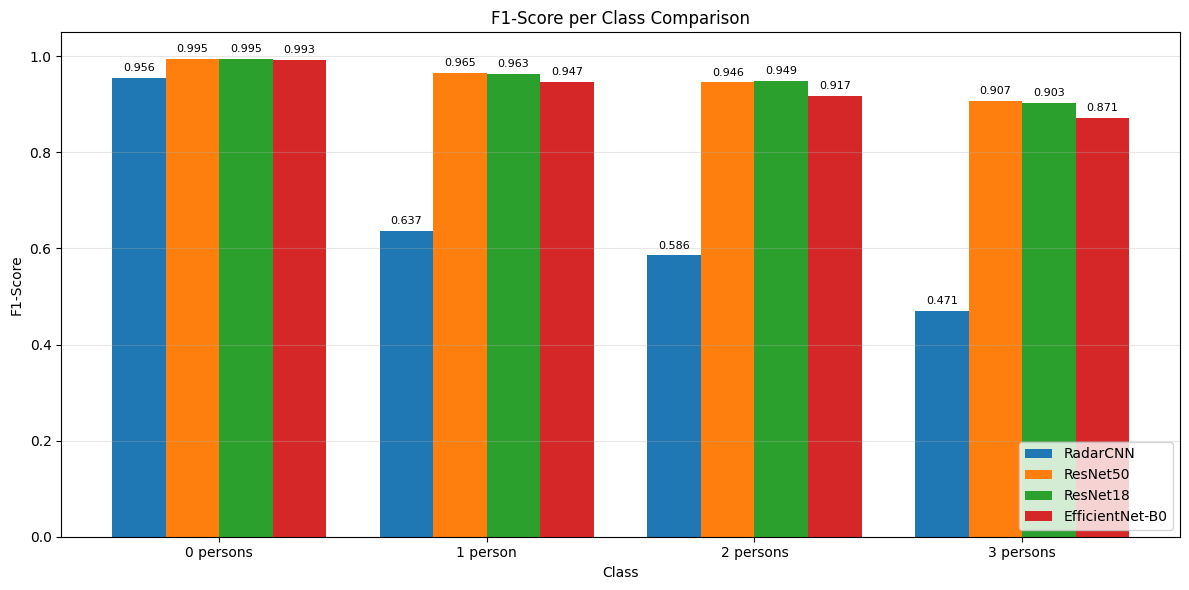

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

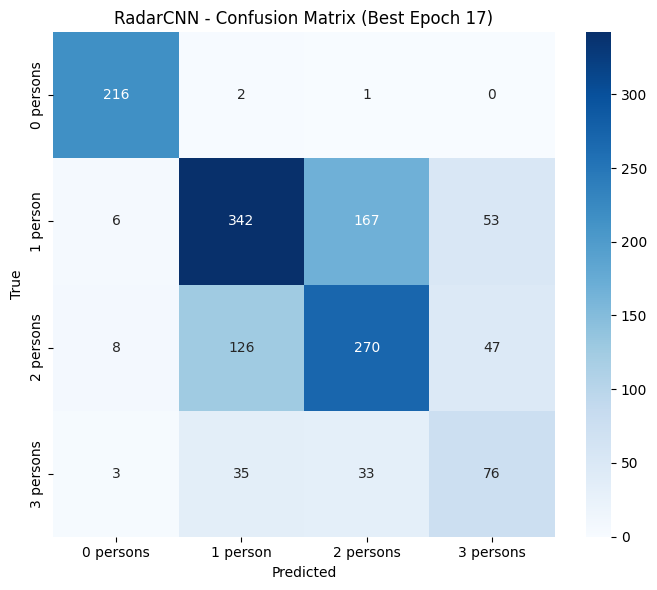

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

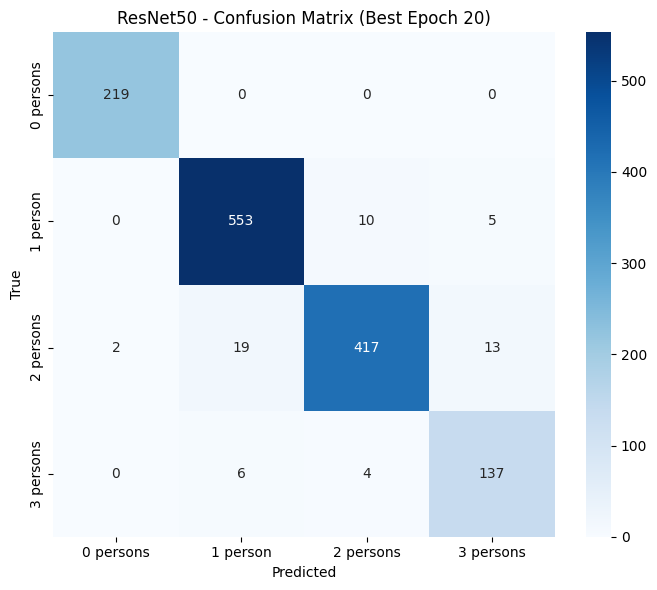

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

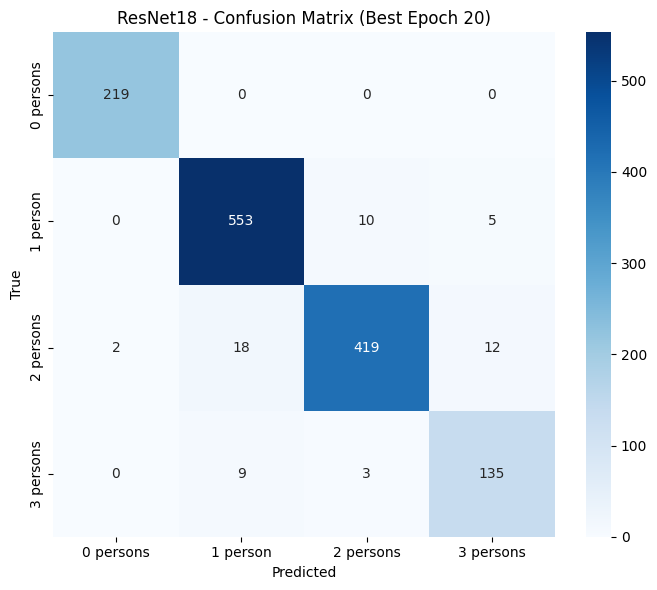

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

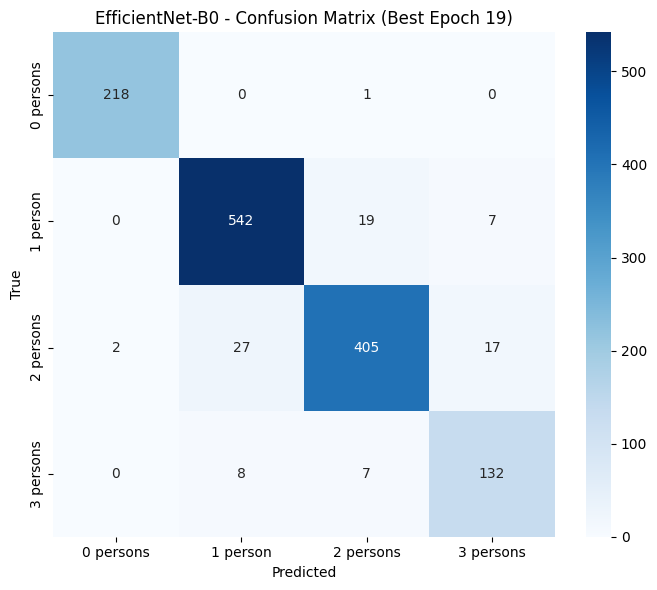



RadarCNN - Best Epoch 17
              precision    recall  f1-score   support

           0     0.9270    0.9863    0.9558       219
           1     0.6772    0.6021    0.6375       568
           2     0.5732    0.5987    0.5857       451
           3     0.4318    0.5170    0.4706       147

    accuracy                         0.6527      1385
   macro avg     0.6523    0.6760    0.6624      1385
weighted avg     0.6568    0.6527    0.6532      1385

Macro F1: 0.6624


ResNet50 - Best Epoch 20
              precision    recall  f1-score   support

           0     0.9910    1.0000    0.9955       219
           1     0.9567    0.9736    0.9651       568
           2     0.9675    0.9246    0.9456       451
           3     0.8839    0.9320    0.9073       147

    accuracy                         0.9574      1385
   macro avg     0.9498    0.9575    0.9534      1385
weighted avg     0.9579    0.9574    0.9574      1385

Macro F1: 0.9534


ResNet18 - Best Epoch 20
              p

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

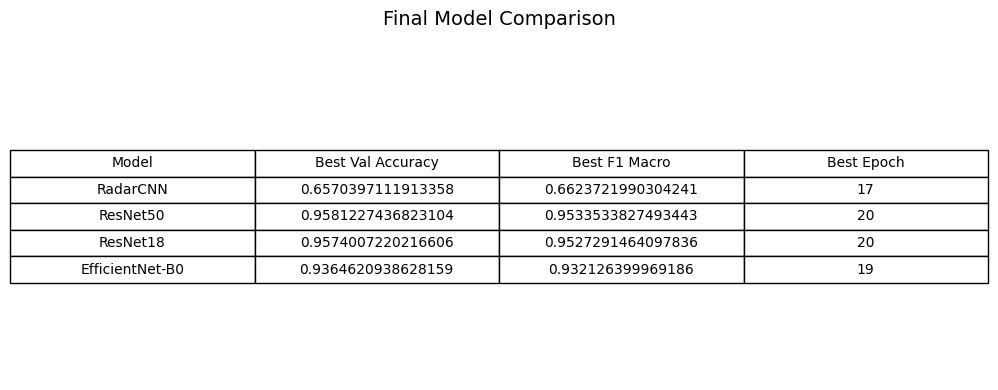

In [ ]:
from google.colab import files

# ------------------------------------------------------------
# GRAPHIC: TRAINING LOSS (4 MODELS)
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
for name, hist in history.items():
    plt.plot(hist["loss"], label=name, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss_comparison.png', dpi=300, bbox_inches='tight')
files.download('training_loss_comparison.png')
plt.show()


# ------------------------------------------------------------
# GRAPHIC: VALIDATION ACCURACY (4 MODELOS)
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
for name, hist in history.items():
    plt.plot(hist["acc"], label=name, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('validation_accuracy_comparison.png', dpi=300, bbox_inches='tight')
files.download('validation_accuracy_comparison.png')
plt.show()


# ------------------------------------------------------------
# GRAPHIC VALIDATION F1 MACRO (4 MODELOS)
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
for name, hist in history.items():
    plt.plot(hist["f1_macro"], label=name, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1-Score")
plt.title("Validation Macro F1-Score Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('validation_f1_macro_comparison.png', dpi=300, bbox_inches='tight')
files.download('validation_f1_macro_comparison.png')
plt.show()


# ------------------------------------------------------------
# TABLE: F1 BY CLASS FOR EACH MODEL
# ------------------------------------------------------------

classes = ["0 persons", "1 person", "2 persons", "3 persons"]

print("\n" + "="*80)
print("F1-SCORE PER CLASS (BEST EPOCH)")
print("="*80)

# Display table on screen
print(f"\n{'Model':<18} {'F1 Macro':<10} {'C0':<8} {'C1':<8} {'C2':<8} {'C3':<8} {'Epoch':<6}")
print("-" * 70)

for name, hist in history.items():
    f1 = hist["best_f1_per_class"]
    print(f"{name:<18} {hist['best_f1']:<10.4f} {f1[0]:<8.4f} {f1[1]:<8.4f} {f1[2]:<8.4f} {f1[3]:<8.4f} {hist['best_epoch']+1:<6}")


# ------------------------------------------------------------
# BAR CHART: F1 BY CLASS
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(classes))
width = 0.2
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (name, hist) in enumerate(history.items()):
    f1_per_class = hist["best_f1_per_class"]
    bars = ax.bar(x + i*width, f1_per_class, width, label=name, color=colors[i % len(colors)])
    # Add values on top of bars
    for j, (x_pos, score) in enumerate(zip(x + i*width, f1_per_class)):
        ax.text(x_pos, score + 0.01, f'{score:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Class')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score per Class Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(classes)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('f1_score_per_class_comparison.png', dpi=300, bbox_inches='tight')
files.download('f1_score_per_class_comparison.png')
plt.show()


# ------------------------------------------------------------
# CONFUSION MATRICES (for each model)
# ------------------------------------------------------------

for name, hist in history.items():
    cm = confusion_matrix(hist["gt"], hist["preds"])

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f"{name} - Confusion Matrix (Best Epoch {hist['best_epoch']+1})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name}.png', dpi=300, bbox_inches='tight')
    files.download(f'confusion_matrix_{name}.png')
    plt.show()


# ------------------------------------------------------------
# CLASSIFICATION REPORTS (for each model)
# ------------------------------------------------------------

for name, hist in history.items():
    print("\n")
    print("="*60)
    print(f"{name} - Best Epoch {hist['best_epoch']+1}")
    print("="*60)
    print(classification_report(hist["gt"], hist["preds"], digits=4))
    print(f"Macro F1: {hist['best_f1']:.4f}")


# ------------------------------------------------------------
# FINAL COMPARISON (TABLE)
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": list(history.keys()),
    "Best Val Accuracy": [history[m]["best_acc"] for m in history],
    "Best F1 Macro": [history[m]["best_f1"] for m in history],
    "Best Epoch": [history[m]["best_epoch"] + 1 for m in history]
})

print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(comparison.to_string(index=False))

# Best model
best_model = max(history.keys(), key=lambda x: history[x]["best_f1"])
print(f"BEST MODEL: {best_model}")
print(f"   F1 Macro: {history[best_model]['best_f1']:.4f}")
print(f"   Accuracy: {history[best_model]['best_acc']:.4f}")


# ------------------------------------------------------------
# SAVE COMPARATIVE TABLE AS IMAGE
# ------------------------------------------------------------

# Create a shape for the comparison table
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table_data = [comparison.columns.values.tolist()] + comparison.values.tolist()
table = ax.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('Final Model Comparison', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('final_model_comparison_table.png', dpi=300, bbox_inches='tight')
files.download('final_model_comparison_table.png')
plt.show()

In [ ]:

# ------------------------------------------------------------
# TEST ENSEMBLE (kept the same)
# ------------------------------------------------------------

test_ds = RadarDataset(TEST, transform=val_tf)
test_loader = DataLoader(test_ds, batch_size=32)

predictions = []
models_list = [model1, model2]  # Now with 4 models

for x, names in test_loader:
    x = x.to(device)

    with torch.no_grad():
        probs = 0
        for model in models_list:
            tta = 0
            for _ in range(5):
                out = model(x)
                tta += torch.softmax(out, dim=1)
            probs += tta / 5

        probs /= len(models_list)
        pred = probs.argmax(1)
        predictions.extend(pred.cpu().numpy())

example_csv = os.path.join(base_path, "y_test_submission_example_v2.csv")
sub = pd.read_csv(example_csv)
sub["target"] = predictions
sub.to_csv("submission_4models_ensemble.csv", index=False)

print("\n✅ SUBMISSION READY: submission_4models_ensemble.csv")


✅ SUBMISSION READY: submission_4models_ensemble.csv


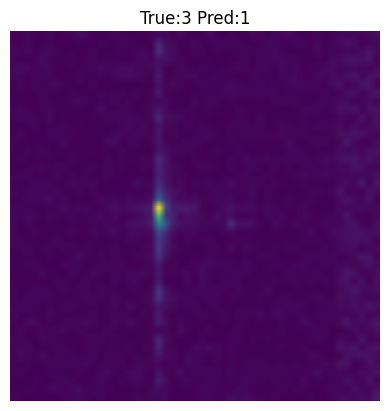

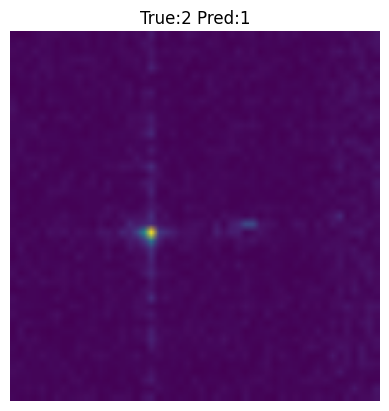

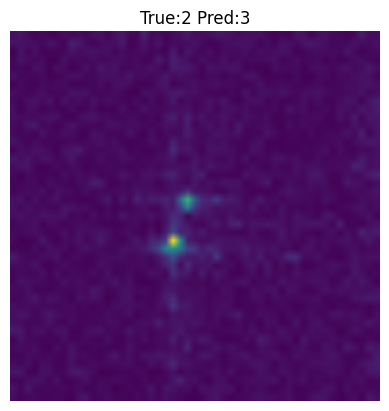

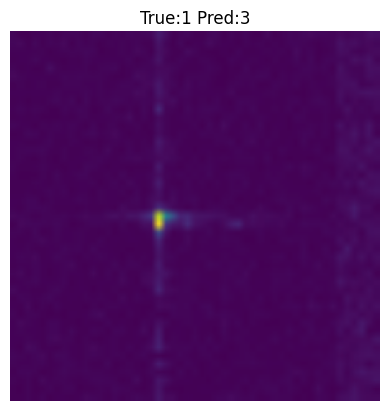

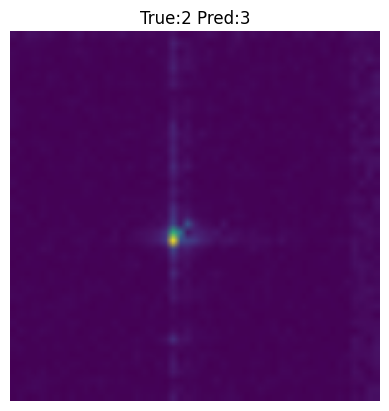

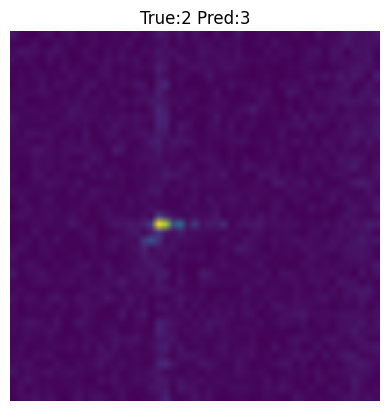

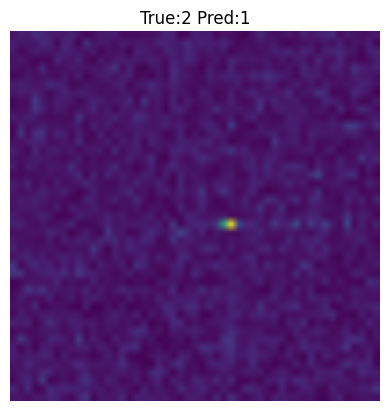

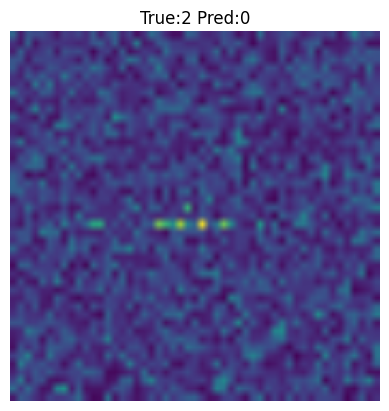

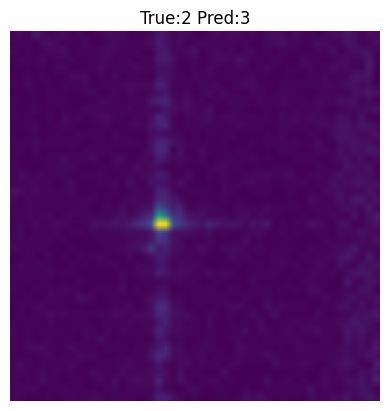

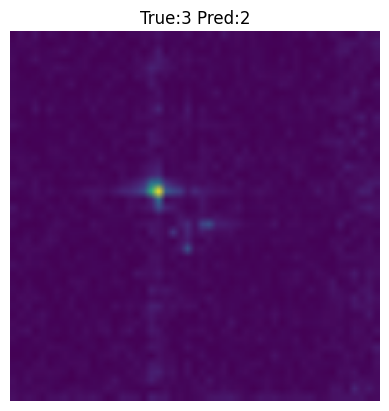

In [ ]:
# ------------------------------------------------------------
# MISCLASSIFIED EXAMPLES
# ------------------------------------------------------------

model2.eval()

shown=0

for x,y in val_loader:

 x=x.to(device)

 with torch.no_grad():
   p=model2(x).argmax(1)

 wrong=(p.cpu()!=y)

 if wrong.any():

   ids=np.where(
    wrong.numpy()
   )[0]

   for i in ids[:5]:

      img=x[i].cpu().permute(
       1,2,0
      ).numpy()

      img=img*[
       0.229,0.224,0.225
      ]+[
       0.485,0.456,0.406
      ]

      plt.figure()

      plt.imshow(
       np.clip(img,0,1)
      )

      plt.title(
       f"True:{y[i]} Pred:{p[i].item()}"
      )

      plt.axis("off")
      plt.show()

      shown+=1

      if shown>=10:
         break

 if shown>=10:
    break

